# FWC time series with SIC

In [23]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:37045")
client

<Client: 'tcp://127.0.0.1:37045' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [7]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
theta_beaufort = theta_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

## 1. Select days after sea ice minimum each year and mask SIC>15%

In [8]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))
beaufort_area = HH_grid.isel(i=slice(450,750),j=slice(110,390)).rAc

In [9]:
# calculating minimum based on extend (count grid cells where ice concentration >= 15% and sum their areas)

# salculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_beaufort >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_ice_dates = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_ice_dates.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

2014: Minimum extent on 2014-09-23T12:00:00.000000000
2015: Minimum extent on 2015-09-16T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-07T12:00:00.000000000
2018: Minimum extent on 2018-09-21T12:00:00.000000000
2019: Minimum extent on 2019-09-24T12:00:00.000000000
2020: Minimum extent on 2020-09-06T12:00:00.000000000


In [10]:
# generate daily timestamps from each min date to Dec 31 of that year
date_arrays = [np.arange(np.datetime64(date), np.datetime64(f"{str(date)[:4]}-12-31") + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))
               for date in min_ice_dates]

# concatenate into one array
full_date_array = np.concatenate(date_arrays)

In [11]:
# select days after sea ice minimum for SIC and salinity

# select all timesteps after sea ice minimum each year
ice_yrs = ice_beaufort.sel(time=full_date_array)
# salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,8)) # only upper 12 m
salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,7)) # only upper 10 m

In [12]:
# look at depth of grid cell center and bottom of grid cell
print(salt_yrs.Z.values)
print(HH_grid.isel(k_u=slice(0,7)).Zu.values)

[-0.5   -1.57  -2.79  -4.185 -5.78  -7.595 -9.66 ]
[ -1.    -2.14  -3.44  -4.93  -6.63  -8.56 -10.76]


In [13]:
# list to store yearly masks
mask_list = []

for date in min_ice_dates:
    year = str(date.astype('datetime64[Y]'))  # Extract year as a string
    
    # select all days from the minimum ice date to Dec 31
    yearly_data = ice_yrs.sel(time=slice(str(date), f"{year}-12-31"))

    # get sea ice concentration on the minimum ice date
    sic_min_day = ice_yrs.sel(time=date)

    # create a mask for grid cells where sic >= 15% on the minimum ice date
    mask = sic_min_day >= 15  # 2D (i, j)

    # expand mask along time dimension to match yearly_data
    mask_expanded = mask.expand_dims(dim={"time": yearly_data.time}, axis=0)

    # store in list
    mask_list.append(mask_expanded)

# combine all yearly masks
sic_yrs_mask = xr.concat(mask_list, dim="time").combine_first(ice_yrs * 0)  # Align time with ice_yrs

# apply mask to sea ice ds
land_sic_mask_yr = (~sic_yrs_mask.astype(bool)) & (HH_grid.isel(i=slice(450,750),j=slice(110,390),k=0).mask_basin)
ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)

## 2. Calculate FWC

In [14]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [15]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

# dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,8)) # upper 12
# dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,7)) # upper 10
dz = HH_grid.isel(i=slice(510,590),j=slice(140,260)).drF.isel(k=slice(0,7)) # upper 10

fwc_beaufort_yrs = calculate_fwc(salt_yrs, salt_ref, dz)

In [16]:
# mask land grid cells and where SIC>15% on ice minimum date
# ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)
fwc_yrs_masked = fwc_beaufort_yrs.where(land_sic_mask_yr)

In [17]:
fwc_over_2m = fwc_yrs_masked.where(fwc_yrs_masked>2)
fwc_under_2m = fwc_yrs_masked.where(fwc_yrs_masked<2)

## 3a. Group FWC>2 and calculate mean SIC for time series

In [18]:
# open FWC dataset
fwc_yrs_masked = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_masked_Beaufort.ZARR')
fwc_yrs_masked = fwc_yrs_masked.fwc_yrs_masked

In [19]:
# select all cells with FWC>2
ice_fwc_over_2m = ice_yrs_masked.where(fwc_yrs_masked>2).load()
ice_fwc_under_2m = ice_yrs_masked.where(fwc_yrs_masked<2).load()

In [20]:
# calculate avg
ice_fwc_over_2m_avg = ice_fwc_over_2m.mean(dim=['i','j'])
ice_fwc_under_2m_avg = ice_fwc_under_2m.mean(dim=['i','j'])

# calculate standard error
n_obs_over = ice_fwc_over_2m.count(dim=['i', 'j'])
ice_fwc_over_2m_se = ice_fwc_over_2m.std(dim=['i', 'j']) / np.sqrt(n_obs_over)
n_obs_under = ice_fwc_under_2m.count(dim=['i', 'j'])
ice_fwc_under_2m_se = ice_fwc_under_2m.std(dim=['i', 'j']) / np.sqrt(n_obs_under)

### Add vertical lines for where SIC>=15% and remain above it for at least 5 days


In [21]:
# first day when sea ice concentration (SIC) reaches or exceeds 15% and stays above that threshold for at least 5 consecutive days
years = np.arange(2014, 2021)

ice_fwc_over_2m_dates = []
ice_fwc_under_2m_dates = []

for year in years:
    # Compute mean SIC over space
    ice_over_mean = ice_fwc_over_2m.sel(time=str(year)).mean(dim=['i', 'j'], skipna=True).compute()
    ice_under_mean = ice_fwc_under_2m.sel(time=str(year)).mean(dim=['i', 'j'], skipna=True).compute()
    
    # Convert to boolean where SIC >= 15
    ice_over_bool = ice_over_mean >= 15
    ice_under_bool = ice_under_mean >= 15

    # Find the first day where there are 5+ consecutive True values
    def find_persistent_threshold(bool_array, time_array, window=5):
        bool_np = bool_array.values
        for i in range(len(bool_np) - window + 1):
            if np.all(bool_np[i:i+window]):
                return time_array[i].values
        return np.datetime64('NaT')  # If no valid period found

    over_time = ice_over_mean['time']
    under_time = ice_under_mean['time']

    ice_over_date = find_persistent_threshold(ice_over_bool, over_time)
    ice_under_date = find_persistent_threshold(ice_under_bool, under_time)

    ice_fwc_over_2m_dates.append(ice_over_date)
    ice_fwc_under_2m_dates.append(ice_under_date)

### Standard deviation

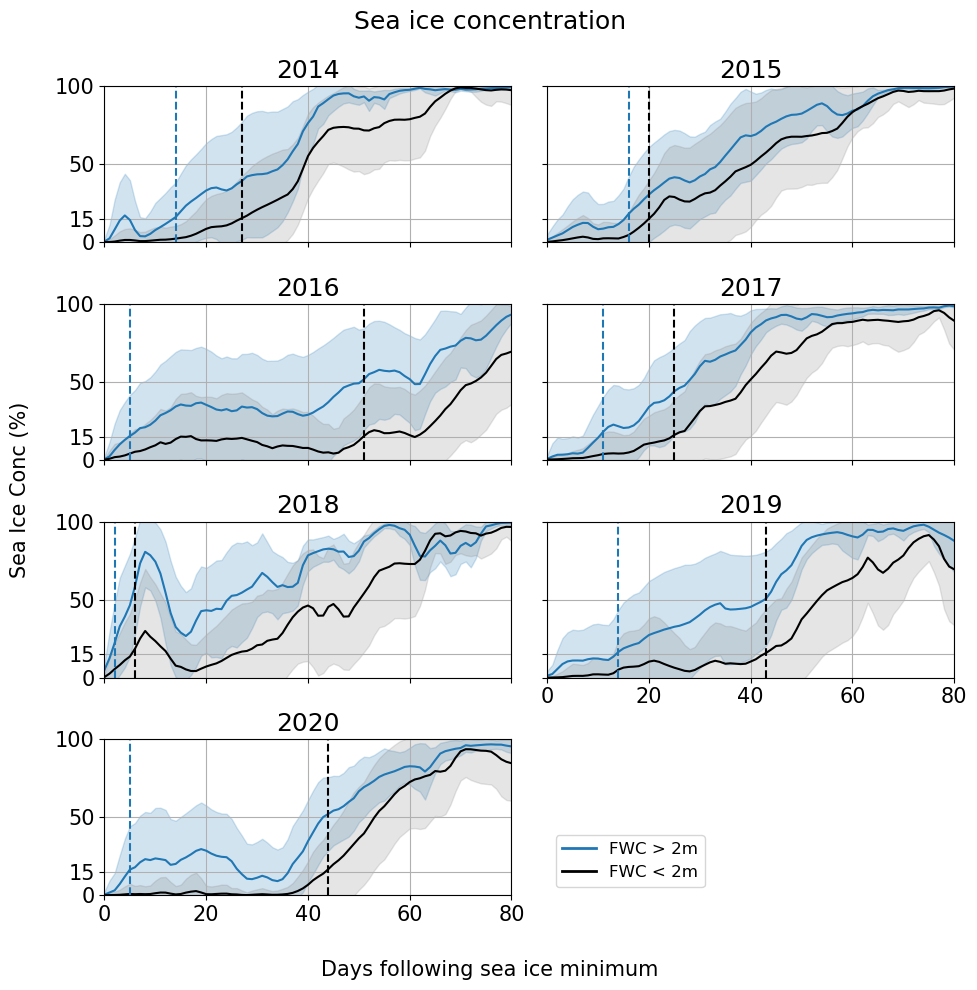

In [24]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True, sharey=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = ice_fwc_over_2m.sel(time=str(year))
    data_under = ice_fwc_under_2m.sel(time=str(year))

    # Find first day when sea ice exists (mean_over is not NaN or > 0)
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()
    
    # Extract the shifted data starting from sea ice onset
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    # Recalculate SE for the sliced data
    data_over_slice = data_over.isel(time=slice(first_valid_index, None))
    data_under_slice = data_under.isel(time=slice(first_valid_index, None))

    std_over = data_over_slice.std(dim=['i', 'j'])
    std_under = data_under_slice.std(dim=['i', 'j'])

    # Reset x-axis to be relative to the start of sea ice
    doy_shifted = np.arange(len(mean_over))

    # Plot
    ax.plot(doy_shifted, mean_over, color='tab:blue', label='FWC > 2m')
    ax.fill_between(doy_shifted, mean_over - std_over, mean_over + std_over, color='tab:blue', alpha=0.2)

    ax.plot(doy_shifted, mean_under, color='k', label='FWC < 2m')
    ax.fill_between(doy_shifted, mean_under - std_under, mean_under + std_under, color='gray', alpha=0.2)

    # add vertical lines for where SIC > 15%
    ax.axvline(x=np.where(data_over_slice.time.values == ice_fwc_over_2m_dates[i])[0][0], color='tab:blue', linestyle='dashed')
    ax.axvline(x=np.where(data_under_slice.time.values == ice_fwc_under_2m_dates[i])[0][0], color='k', linestyle='dashed')

    ax.set_title(f"{year}")
    ax.set_xlim([0, 80])
    ax.set_ylim([0, 100])
    ax.set_yticks([0,15,50,100])
    ax.grid(True)

    if i == 5:
        ax.tick_params(labelbottom=True)        
    
# axes[6].set_xlabel("Days following sea ice minimum")

# Custom legend handles
custom_lines = [Line2D([0], [0], color='tab:blue', lw=2),\
                Line2D([0], [0], color='k', lw=2)]

# Only show legend in the bottom right subplot
if len(years) < len(axes):
    axes[-1].axis('off')

axes[-1].legend(
    custom_lines, ['FWC > 2m', 'FWC < 2m'],
    loc='lower left',
    fontsize=12,
    title_fontsize=13)

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("Sea Ice Conc (%)", fontsize=15)
fig.suptitle("Sea ice concentration")

plt.tight_layout()
plt.show()

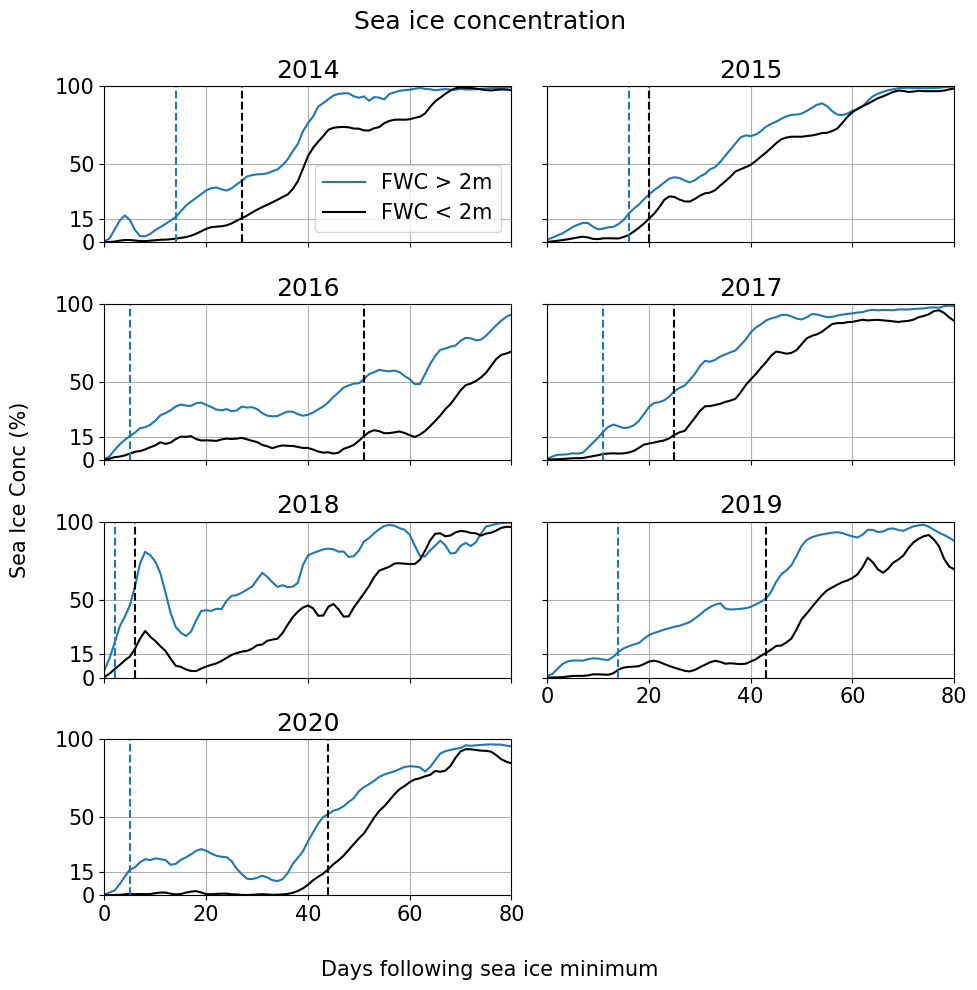

In [40]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True, sharey=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = ice_fwc_over_2m.sel(time=str(year))
    data_under = ice_fwc_under_2m.sel(time=str(year))

    # Find first day when sea ice exists (mean_over is not NaN or > 0)
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()
    
    # Extract the shifted data starting from sea ice onset
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    # Recalculate SE for the sliced data
    data_over_slice = data_over.isel(time=slice(first_valid_index, None))
    data_under_slice = data_under.isel(time=slice(first_valid_index, None))

    std_over = data_over_slice.std(dim=['i', 'j'])
    std_under = data_under_slice.std(dim=['i', 'j'])

    # Reset x-axis to be relative to the start of sea ice
    doy_shifted = np.arange(len(mean_over))

    # Plot
    ax.plot(doy_shifted, mean_over, color='tab:blue', label='FWC > 2m')
    # ax.fill_between(doy_shifted, mean_over - std_over, mean_over + std_over, color='tab:blue', alpha=0.2)

    ax.plot(doy_shifted, mean_under, color='k', label='FWC < 2m')
    # ax.fill_between(doy_shifted, mean_under - std_under, mean_under + std_under, color='gray', alpha=0.2)

    # add vertical lines for where SIC > 15%
    ax.axvline(x=np.where(data_over_slice.time.values == ice_fwc_over_2m_dates[i])[0][0], color='tab:blue', linestyle='dashed')
    ax.axvline(x=np.where(data_under_slice.time.values == ice_fwc_under_2m_dates[i])[0][0], color='k', linestyle='dashed')

    ax.set_title(f"{year}")
    ax.set_xlim([0, 80])
    ax.set_ylim([0, 100])
    ax.set_yticks([0,15,50,100])
    ax.grid(True)

    if i == 5:
        ax.tick_params(labelbottom=True)        
    
# axes[6].set_xlabel("Days following sea ice minimum")

# Turn off the last axis if unused (e.g., 8th subplot)
if len(years) < len(axes):
    axes[-1].axis('off')

# Add legend to the first axis
axes[0].legend(loc='lower right')

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("Sea Ice Conc (%)", fontsize=15)
fig.suptitle("Sea ice concentration")

plt.tight_layout()
plt.show()

## Calculate difference in rate of change of sea ice formation

In [33]:
# daily change in sea ice concentration ([%/day]), and then the difference between the two water masses
ice_rate_over = ice_fwc_over_2m.diff(dim='time')
ice_rate_under = ice_fwc_under_2m.diff(dim='time')
ice_rate_diff = ice_rate_over.mean(dim=['i','j']) - ice_rate_under.mean(dim=['i','j'])

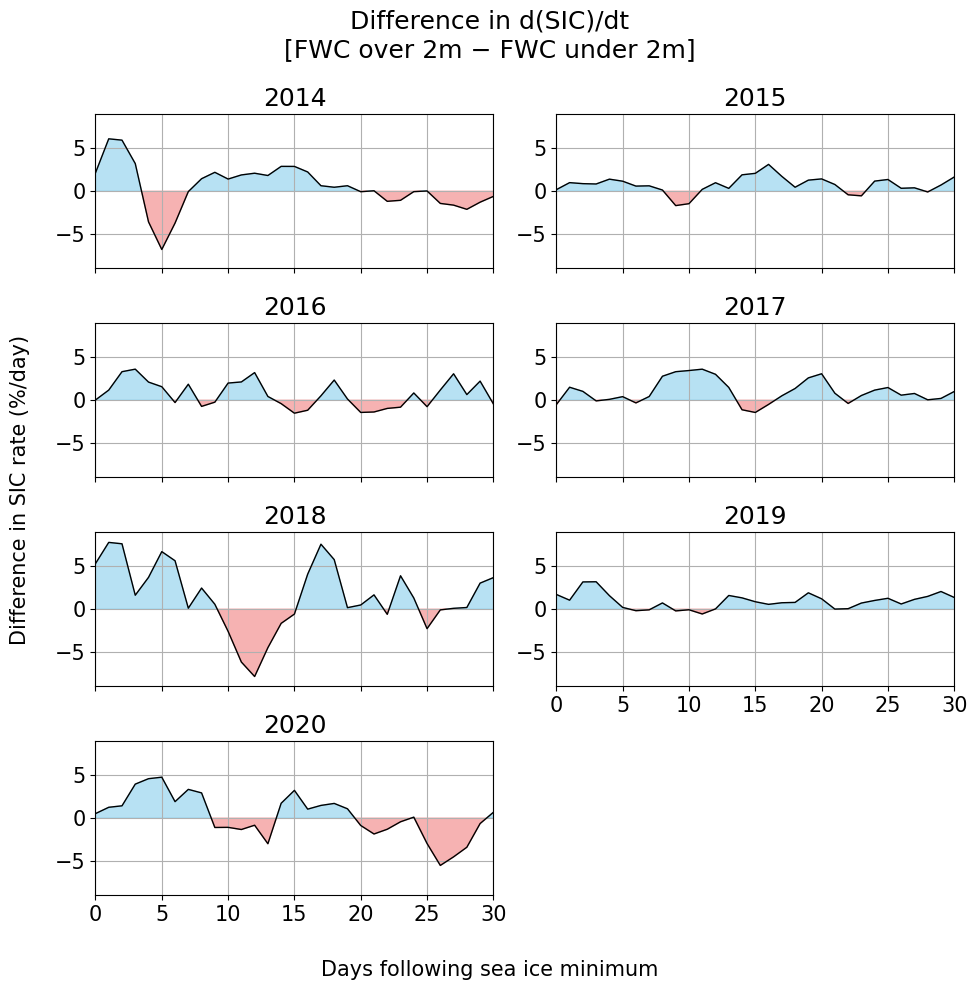

In [39]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_yr = ice_rate_diff.sel(time=str(year))

    # Find first day when sea ice exists (not null)
    first_valid_index = data_yr.notnull().argmax().compute().item()

    # Extract the shifted data starting from sea ice onset
    rate_yr_shifted = data_yr.isel(time=slice(first_valid_index, None))

    # Reset x-axis to be relative to sea ice onset
    doy_shifted = np.arange(len(rate_yr_shifted))

    # Plot black line
    ax.plot(doy_shifted, rate_yr_shifted, color='black', linewidth=1, label='Δ sea ice growth rate')

    # Shade area above zero (light blue)
    ax.fill_between(
        doy_shifted,
        0,
        rate_yr_shifted,
        where=rate_yr_shifted > 0,
        interpolate=True,
        color='skyblue',
        alpha=0.6
    )

    # Shade area below zero (light red)
    ax.fill_between(
        doy_shifted,
        0,
        rate_yr_shifted,
        where=rate_yr_shifted < 0,
        interpolate=True,
        color='lightcoral',
        alpha=0.6
    )

    # Title and axes config
    ax.set_title(f"{year}")
    ax.set_xlim([0, 30])
    ax.set_ylim([-9, 9])
    ax.grid(True)

    if i == 5:
        ax.tick_params(labelbottom=True)       

# Turn off the last axis if unused (e.g., 8th subplot)
if len(years) < len(axes):
    axes[-1].axis('off')

# Add legend to the first axis
# axes[0].legend(loc='lower right')

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("Difference in SIC rate (%/day)", fontsize=15)
fig.suptitle("Difference in d(SIC)/dt\n[FWC over 2m − FWC under 2m]")

plt.tight_layout()
plt.show()

## 3a. Group FWC>3.5 and calculate mean SIC for time series

In [111]:
# select all cells with FWC>3.5
ice_fwc_over_2m = ice_yrs_masked.where(fwc_yrs_masked>3)
ice_fwc_under_2m = ice_yrs_masked.where(fwc_yrs_masked<2)

In [112]:
ice_fwc_over_2m_avg = ice_fwc_over_2m.mean(dim=['i','j'])
ice_fwc_under_2m_avg = ice_fwc_under_2m.mean(dim=['i','j'])

ice_fwc_over_2m_avg = ice_fwc_over_2m.std(dim=['i','j'])
ice_fwc_under_2m_avg = ice_fwc_under_2m.std(dim=['i','j'])

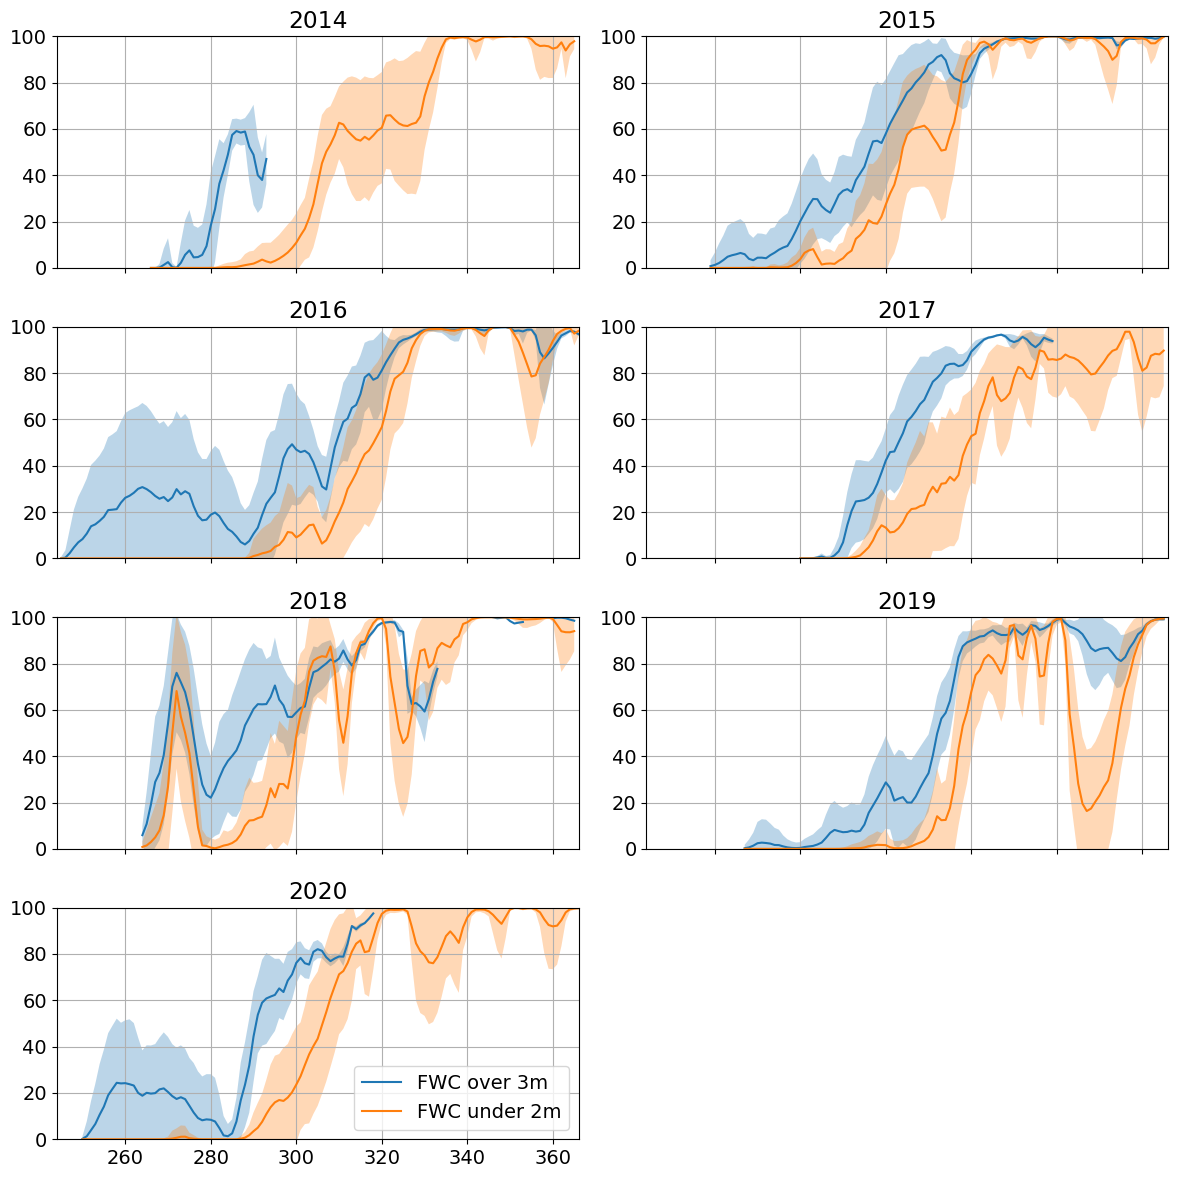

In [113]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[12, 12], sharex=True)
plt.rcParams['font.size'] = 14
axes = axes.flatten()

# Compute mean and std over all time
full_mean_over = ice_fwc_over_2m.mean(dim=['i', 'j'])
full_std_over = ice_fwc_over_2m.std(dim=['i', 'j'])

full_mean_under = ice_fwc_under_2m.mean(dim=['i', 'j'])
full_std_under = ice_fwc_under_2m.std(dim=['i', 'j'])

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = ice_fwc_over_2m.sel(time=str(year))
    data_under = ice_fwc_under_2m.sel(time=str(year))

    # Get time as day-of-year
    doy = data_over['time'].dt.dayofyear

    # Mean over i,j for this year's time series
    mean_over = data_over.mean(dim=['i','j'])
    mean_under = data_under.mean(dim=['i','j'])

    # Use full std for shading
    std_over = full_std_over.sel(time=mean_over['time'])
    std_under = full_std_under.sel(time=mean_under['time'])

    # Plot mean with global std shading
    ax.plot(doy, mean_over, label='FWC over 3m')
    ax.fill_between(doy, mean_over - std_over, mean_over + std_over, alpha=0.3)

    ax.plot(doy, mean_under, label='FWC under 2m')
    ax.fill_between(doy, mean_under - std_under, mean_under + std_under, alpha=0.3)

    ax.set_title(f"{year}")
    ax.set_xlim([244, 366])
    ax.set_ylim([0,100])
    ax.grid(True)

# Turn off the last axis if unused (8th subplot)
if len(years) < len(axes):
    axes[-1].axis('off')

# Add legend to the last used axis
axes[len(years) - 1].legend(loc='lower right')

plt.tight_layout()
plt.show()